# Лабораторная работа №2
## Реализация и исследование DDPM

**Курс:** Генеративные и мультимодальные сети
**Максимальный балл:** 25  

---

### Цель работы
Реализовать с нуля Denoising Diffusion Probabilistic Model (DDPM), изучить влияние ключевых гиперпараметров и сравнить с ускоренным сэмплированием DDIM.

### Система оценки
| Задание | Баллы |
|---------|-------|
| Корректная реализация forward + reverse process | 7 |
| U-Net архитектура с time-conditioning | 5 |
| Эксперименты с гиперпараметрами (таблица + выводы) | 6 |
| Сравнение DDPM vs DDIM | 4 |
| Качество визуализаций и оформление | 3 |

### Что сдавать
- Заполненный ноутбук (все ячейки выполнены)


## 0. Установка зависимостей


In [1]:
import sys
import subprocess

try:
    import torch
    import torchvision
    import einops
    import diffusers
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "torch",
        "torchvision",
        "diffusers",
        "accelerate",
        "matplotlib",
        "einops",
        "pandas",
        "--quiet",
    ])


## 1. Импорты и конфигурация


In [ ]:
import os
import time
import math
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Устройство: {device}")

RUN_MODE = "balanced"

T = 500
IMG_SIZE = 32
IN_CHANNELS = 3
LR = 2e-4
TIME_EMB_DIM = 128
NUM_WORKERS = 0
SAMPLE_EVERY = 5
PREVIEW_STEPS = 75
DDIM_STEPS_LIST = [150, 75, 40]
FULL_DDPM_SAMPLES = 8
EMA_DECAY = 0.995
CHECKPOINT_DIR = Path("./checkpoints_lab2")
CHECKPOINT_DIR.mkdir(exist_ok=True)

if RUN_MODE == "quick":
    BATCH_SIZE = 96
    NUM_EPOCHS = 8
    BASE_DIM = 48
    TRAIN_SUBSET_SIZE = 20000
elif RUN_MODE == "balanced":
    BATCH_SIZE = 112
    NUM_EPOCHS = 15
    BASE_DIM = 56
    TRAIN_SUBSET_SIZE = 35000
elif RUN_MODE == "quality":
    BATCH_SIZE = 128
    NUM_EPOCHS = 30
    BASE_DIM = 64
    TRAIN_SUBSET_SIZE = None
else:
    raise ValueError("RUN_MODE должен быть 'quick', 'balanced' или 'quality'")

print({
    "RUN_MODE": RUN_MODE,
    "T": T,
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "BASE_DIM": BASE_DIM,
    "TRAIN_SUBSET_SIZE": TRAIN_SUBSET_SIZE,
    "PREVIEW_STEPS": PREVIEW_STEPS,
    "DDIM_STEPS_LIST": DDIM_STEPS_LIST,
    "FULL_DDPM_SAMPLES": FULL_DDPM_SAMPLES,
    "EMA_DECAY": EMA_DECAY,
})


Устройство: mps
{'RUN_MODE': 'balanced', 'T': 500, 'IMG_SIZE': 32, 'BATCH_SIZE': 112, 'NUM_EPOCHS': 15, 'BASE_DIM': 56, 'TRAIN_SUBSET_SIZE': 35000, 'PREVIEW_STEPS': 75, 'DDIM_STEPS_LIST': [150, 75, 40], 'FULL_DDPM_SAMPLES': 8, 'EMA_DECAY': 0.995}


## 2. Загрузка данных

> Используем CIFAR-10.


DATA_ROOT: /Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1
Train: 35000 Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch shape: torch.Size([112, 3, 32, 32])
Min: -1.00, Max: 1.00


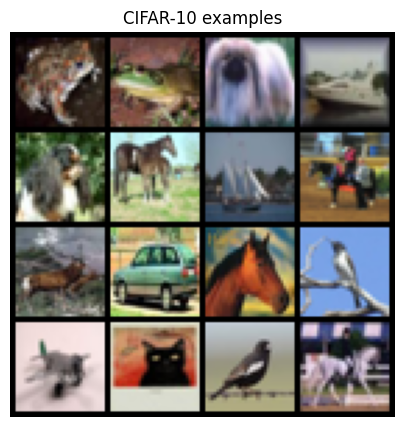

In [ ]:
def find_cifar_root():
    candidates = [
        Path("./data"),
        Path("/Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1"),
        Path.home() / ".cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1",
        Path.home() / "Downloads/data",
    ]

    for candidate in candidates:
        if (candidate / "cifar-10-batches-py").exists():
            return str(candidate)

    raise FileNotFoundError(
        "where cifar-10-batches-py. "
        "go kagglehub: "
        "kagglehub.dataset_download('xusaiai/cifar-10-pythontargz')."
    )

DATA_ROOT = find_cifar_root()
print("DATA_ROOT:", DATA_ROOT)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=transform,
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=False,
    transform=transform,
)

if TRAIN_SUBSET_SIZE is not None:
    generator = torch.Generator().manual_seed(SEED)
    indices = torch.randperm(len(full_train_dataset), generator=generator)[:TRAIN_SUBSET_SIZE].tolist()
    train_dataset = Subset(full_train_dataset, indices)
else:
    train_dataset = full_train_dataset

dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

classes = full_train_dataset.classes
imgs, labels = next(iter(dataloader))

print("Train:", len(train_dataset), "Test:", len(test_dataset))
print("Classes:", classes)
print(f"Batch shape: {imgs.shape}")
print(f"Min: {imgs.min():.2f}, Max: {imgs.max():.2f}")

grid = make_grid(imgs[:16], nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("CIFAR-10 examples")
plt.show()


## 3. Noise Schedule

> **Задание:** Реализуйте два расписания шума:
> - **Linear schedule**: β линейно возрастает от β₁ до β_T
> - **Cosine schedule** (Ho et al., 2020): ᾱₜ = cos²((t/T + 0.008) / 1.008 · π/2)
> 
> Вычислите и сохраните:
> - `betas`: βₜ для t = 1..T
> - `alphas`: αₜ = 1 - βₜ
> - `alphas_cumprod`: ᾱₜ = ∏αₛ (s=1..t)
> - `sqrt_alphas_cumprod`, `sqrt_one_minus_alphas_cumprod` — нужны для forward process


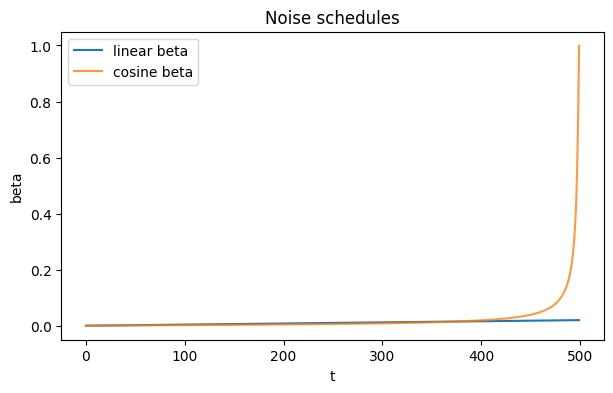

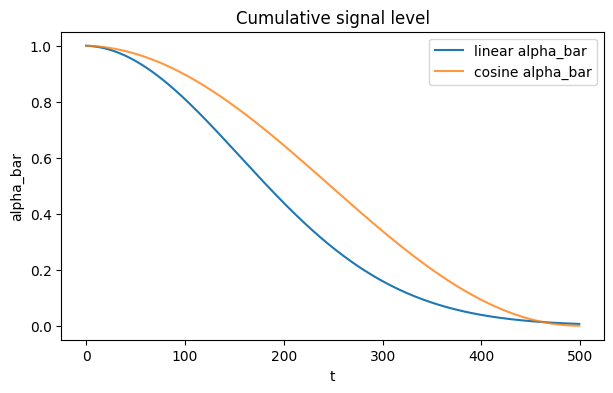

In [ ]:
def _complete_schedule(betas):
    betas = betas.float().clamp(1e-8, 0.999)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([
        torch.ones(1, dtype=alphas_cumprod.dtype),
        alphas_cumprod[:-1],
    ])
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_variance = posterior_variance.clamp(min=1e-20)

    return {
        "betas": betas,
        "alphas": alphas,
        "alphas_cumprod": alphas_cumprod,
        "alphas_cumprod_prev": alphas_cumprod_prev,
        "sqrt_alphas_cumprod": torch.sqrt(alphas_cumprod),
        "sqrt_one_minus_alphas_cumprod": torch.sqrt(1.0 - alphas_cumprod),
        "sqrt_recip_alphas": torch.sqrt(1.0 / alphas),
        "posterior_variance": posterior_variance,
    }


def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = torch.linspace(beta_start, beta_end, T)
    return _complete_schedule(betas)


def cosine_schedule(T, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)
    alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return _complete_schedule(betas)


def move_schedule_to_device(schedule, device):
    return {key: value.to(device) for key, value in schedule.items()}

schedule_name = "cosine"
schedule = move_schedule_to_device(cosine_schedule(T), device)
linear_schedule_cpu = linear_schedule(T)
cos_schedule_cpu = cosine_schedule(T)

plt.figure(figsize=(7, 4))
plt.plot(linear_schedule_cpu["betas"].cpu().numpy(), label="linear beta")
plt.plot(cos_schedule_cpu["betas"].cpu().numpy(), label="cosine beta", alpha=0.8)
plt.xlabel("t")
plt.ylabel("beta")
plt.title("Noise schedules")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(linear_schedule_cpu["alphas_cumprod"].cpu().numpy(), label="linear alpha_bar")
plt.plot(cos_schedule_cpu["alphas_cumprod"].cpu().numpy(), label="cosine alpha_bar", alpha=0.8)
plt.xlabel("t")
plt.ylabel("alpha_bar")
plt.title("Cumulative signal level")
plt.legend()
plt.show()


## 4. Forward Process (добавление шума)

> **Задание:** Реализуйте `q(xₜ | x₀)` — аналитическое добавление шума за один шаг:
> 
> `xₜ = √(ᾱₜ) · x₀ + √(1 - ᾱₜ) · ε`, где `ε ~ N(0, I)`
> 
> Это ключевое свойство DDPM — мы можем получить `xₜ` **напрямую из `x₀`** без итерации!


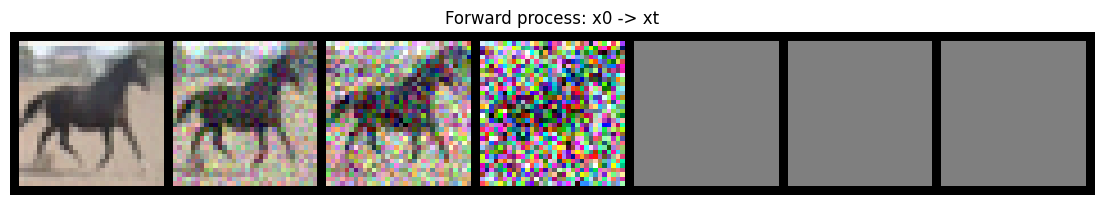

In [5]:
def extract(values, t, x_shape):
    out = values.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(x0, t, schedule, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ac = extract(schedule["sqrt_alphas_cumprod"], t, x0.shape)
    sqrt_one_minus_ac = extract(schedule["sqrt_one_minus_alphas_cumprod"], t, x0.shape)
    xt = sqrt_ac * x0 + sqrt_one_minus_ac * noise
    return xt, noise


imgs, _ = next(iter(dataloader))
x0 = imgs[:1].to(device)
steps_to_show = [0, 50, 100, 250, 500, 750, 999]

noisy_images = []
for step in steps_to_show:
    t = torch.tensor([step], device=device, dtype=torch.long)
    xt, _ = q_sample(x0, t, schedule)
    noisy_images.append(xt.cpu())

noisy_images = torch.cat(noisy_images, dim=0)
grid = make_grid(noisy_images, nrow=len(steps_to_show), normalize=True, value_range=(-1, 1))
plt.figure(figsize=(14, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Forward process: x0 -> xt")
plt.show()


## 5. U-Net с Time Conditioning

> **Задание:** Реализуйте U-Net, который принимает на вход **зашумлённое изображение `xₜ`** и **временной шаг `t`** и предсказывает добавленный шум `ε`.
> 
> **Архитектура:**
> - **Time embedding**: `t` → sinusoidal embedding → 2× Linear → добавляется к feature maps
> - **Encoder**: 3–4 уровня downsampling (Conv + GroupNorm + SiLU)
> - **Bottleneck**: 2× ResBlock
> - **Decoder**: 3–4 уровня upsampling + skip connections из encoder
> 
> **Упрощение:** Для MNIST можно использовать простой U-Net без attention.


In [6]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        scale = math.log(10000) / max(half_dim - 1, 1)
        frequencies = torch.exp(torch.arange(half_dim, device=t.device) * -scale)
        args = t.float()[:, None] * frequencies[None, :]
        emb = torch.cat((args.sin(), args.cos()), dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


def make_group_norm(channels):
    groups = min(8, channels)
    while channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, channels)


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = make_group_norm(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = make_group_norm(out_ch)
        self.time_proj = nn.Linear(time_emb_dim, out_ch)
        self.activation = nn.SiLU()
        self.residual = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.activation(h)
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)
        return h + self.residual(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, base_dim=32, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.init_conv = nn.Conv2d(in_channels, base_dim, kernel_size=3, padding=1)

        self.down1 = Block(base_dim, base_dim, time_emb_dim)
        self.downsample1 = nn.Conv2d(base_dim, base_dim * 2, kernel_size=4, stride=2, padding=1)
        self.down2 = Block(base_dim * 2, base_dim * 2, time_emb_dim)
        self.downsample2 = nn.Conv2d(base_dim * 2, base_dim * 4, kernel_size=4, stride=2, padding=1)
        self.down3 = Block(base_dim * 4, base_dim * 4, time_emb_dim)

        self.mid1 = Block(base_dim * 4, base_dim * 4, time_emb_dim)
        self.mid2 = Block(base_dim * 4, base_dim * 4, time_emb_dim)

        self.upsample1 = nn.ConvTranspose2d(base_dim * 4, base_dim * 2, kernel_size=4, stride=2, padding=1)
        self.up1 = Block(base_dim * 4, base_dim * 2, time_emb_dim)
        self.upsample2 = nn.ConvTranspose2d(base_dim * 2, base_dim, kernel_size=4, stride=2, padding=1)
        self.up2 = Block(base_dim * 2, base_dim, time_emb_dim)

        self.out_norm = make_group_norm(base_dim)
        self.out_conv = nn.Conv2d(base_dim, in_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.init_conv(x)
        s1 = self.down1(x, t_emb)
        x = self.downsample1(s1)
        s2 = self.down2(x, t_emb)
        x = self.downsample2(s2)
        x = self.down3(x, t_emb)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        x = self.upsample1(x)
        x = torch.cat([x, s2], dim=1)
        x = self.up1(x, t_emb)
        x = self.upsample2(x)
        x = torch.cat([x, s1], dim=1)
        x = self.up2(x, t_emb)

        x = self.out_norm(x)
        x = F.silu(x)
        return self.out_conv(x)


model = SimpleUNet(in_channels=IN_CHANNELS, base_dim=BASE_DIM, time_emb_dim=TIME_EMB_DIM).to(device)
x_test = torch.randn(4, IN_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
t_test = torch.randint(0, T, (4,), device=device)
out = model(x_test, t_test)
print(f"Input: {x_test.shape}, Output: {out.shape}")
print("Parameters:", sum(p.numel() for p in model.parameters()))


Input: torch.Size([4, 3, 32, 32]), Output: torch.Size([4, 3, 32, 32])
Parameters: 4621611


## 6. Обучение DDPM

По умолчанию используется средний режим `balanced`: 15 эпох, 35 000 изображений CIFAR-10, `BASE_DIM = 56`, `T = 500`. Выбрал компромисс между качеством и скоростью из-за ограниченности в ресурсах.

Epoch [1/15] Loss: 0.1380 Time: 133.2s
Epoch [2/15] Loss: 0.0793 Time: 160.9s
Epoch [3/15] Loss: 0.0727 Time: 160.6s
Epoch [4/15] Loss: 0.0703 Time: 180.3s
Epoch [5/15] Loss: 0.0688 Time: 186.1s
Checkpoint: checkpoints_lab2/ddpm_balanced_epoch_5.pt


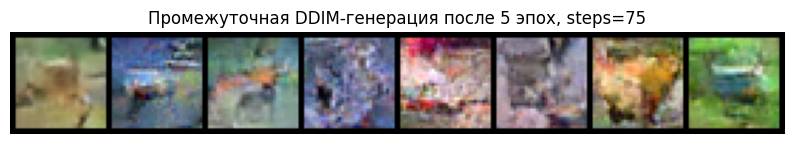

Epoch [6/15] Loss: 0.0684 Time: 177.7s
Epoch [7/15] Loss: 0.0666 Time: 182.0s
Epoch [8/15] Loss: 0.0651 Time: 175.9s
Epoch [9/15] Loss: 0.0651 Time: 178.5s
Epoch [10/15] Loss: 0.0637 Time: 176.5s
Checkpoint: checkpoints_lab2/ddpm_balanced_epoch_10.pt


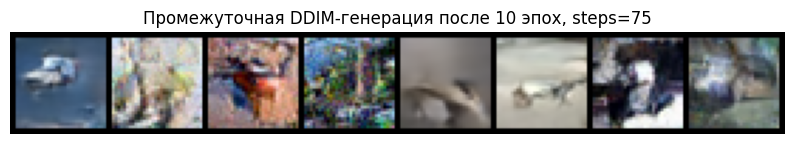

Epoch [11/15] Loss: 0.0645 Time: 189.5s
Epoch [12/15] Loss: 0.0641 Time: 199.7s
Epoch [13/15] Loss: 0.0633 Time: 208.5s
Epoch [14/15] Loss: 0.0634 Time: 208.6s
Epoch [15/15] Loss: 0.0626 Time: 199.0s
Checkpoint: checkpoints_lab2/ddpm_balanced_epoch_15.pt


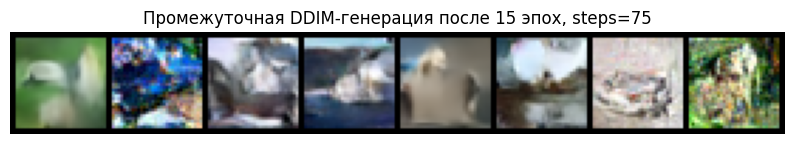

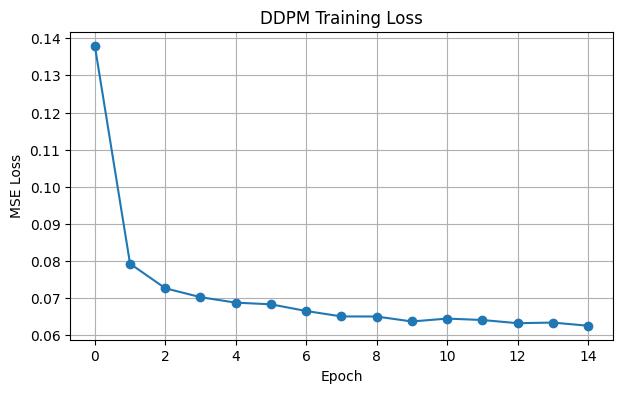

In [7]:
model = SimpleUNet(in_channels=IN_CHANNELS, base_dim=BASE_DIM, time_emb_dim=TIME_EMB_DIM).to(device)
ema_model = deepcopy(model).to(device).eval()
for param in ema_model.parameters():
    param.requires_grad_(False)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses = []
preview_history = {}


def update_ema(ema_model, model, decay):
    with torch.no_grad():
        for ema_param, param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(param.data, alpha=1.0 - decay)


@torch.no_grad()
def sample_ddim_manual(model, shape, schedule, num_steps=100):
    """Корректное ускоренное DDIM-сэмплирование для неполной сетки шагов.

    В предыдущей версии 200 шагов ошибочно выполнялись DDPM-формулой p(x_{t-1}|x_t),
    хотя индексы перескакивали через несколько t. Это давало цветную рябь. Здесь
    используется формула DDIM, которая корректно переносит x_t сразу к выбранному
    предыдущему timestep.
    """
    model.eval()
    x = torch.randn(shape, device=device)
    timesteps = torch.linspace(T - 1, 0, num_steps, device=device).long().unique(sorted=True).flip(0)

    for i, t_val in enumerate(timesteps):
        t_int = int(t_val.item())
        t_batch = torch.full((shape[0],), t_int, device=device, dtype=torch.long)
        eps = model(x, t_batch)

        alpha_bar_t = schedule["alphas_cumprod"][t_int]
        sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
        x0_pred = (x - sqrt_one_minus_alpha_bar_t * eps) / sqrt_alpha_bar_t
        x0_pred = x0_pred.clamp(-1, 1)

        if i == len(timesteps) - 1:
            x = x0_pred
        else:
            prev_t_int = int(timesteps[i + 1].item())
            alpha_bar_prev = schedule["alphas_cumprod"][prev_t_int]
            x = torch.sqrt(alpha_bar_prev) * x0_pred + torch.sqrt(1.0 - alpha_bar_prev) * eps

    return x.clamp(-1, 1).detach().cpu()


for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    start_time = time.time()

    for x0, _ in dataloader:
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.shape[0],), device=device, dtype=torch.long)
        xt, noise = q_sample(x0, t, schedule)
        noise_pred = model(xt, t)
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        update_ema(ema_model, model, EMA_DECAY)

        epoch_loss += loss.item()

    scheduler_lr.step()
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f} Time: {elapsed:.1f}s")

    if (epoch + 1) % SAMPLE_EVERY == 0 or (epoch + 1) == NUM_EPOCHS:
        checkpoint_path = CHECKPOINT_DIR / f"ddpm_{RUN_MODE}_epoch_{epoch + 1}.pt"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "ema_model_state_dict": ema_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_loss,
            "run_mode": RUN_MODE,
            "base_dim": BASE_DIM,
            "schedule_name": schedule_name,
        }, checkpoint_path)
        print("Checkpoint:", checkpoint_path)
        preview_history[epoch + 1] = sample_ddim_manual(
            ema_model,
            shape=(8, IN_CHANNELS, IMG_SIZE, IMG_SIZE),
            schedule=schedule,
            num_steps=PREVIEW_STEPS,
        )
        grid = make_grid(preview_history[epoch + 1], nrow=8, normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(10, 2))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Промежуточная DDIM-генерация после {epoch + 1} эпох, steps={PREVIEW_STEPS}")
        plt.show()

plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DDPM Training Loss")
plt.grid(True)
plt.show()

## 7. Reverse process: DDPM and DDIM

DDPM-сэмплирование выполняется переходом `t -> t-1`. В этой средней версии используется `T = 500`, поэтому полный DDPM быстрее, чем при 1000 шагах, но формула остаётся математически корректной.

Для ещё более быстрой генерации используется DDIM.


Full DDPM sampling time: 8.38s, steps: 500


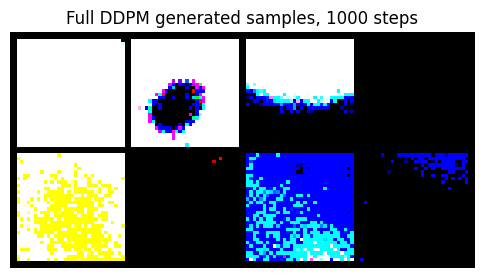

In [8]:
@torch.no_grad()
def p_sample(model, xt, t_val, schedule):
    betas = schedule["betas"]
    alphas = schedule["alphas"]
    alphas_cumprod = schedule["alphas_cumprod"]
    posterior_variance = schedule["posterior_variance"]

    t_tensor = torch.full((xt.shape[0],), t_val, device=xt.device, dtype=torch.long)
    noise_pred = model(xt, t_tensor)

    coef = betas[t_val] / torch.sqrt(1.0 - alphas_cumprod[t_val])
    mean = (1.0 / torch.sqrt(alphas[t_val])) * (xt - coef * noise_pred)

    if t_val == 0:
        return mean

    noise = torch.randn_like(xt)
    return mean + torch.sqrt(posterior_variance[t_val]) * noise


@torch.no_grad()
def sample_ddpm_full(model, shape, schedule):
    """Полный DDPM reverse process: 1000 -> 999 -> ... -> 0.

    DDPM нельзя просто запускать на 200 равномерно выбранных шагах той же формулой:
    такая формула рассчитана на переход t -> t-1. Для ускорения ниже используется DDIM.
    """
    model.eval()
    x = torch.randn(shape, device=device)

    for t_val in range(T - 1, -1, -1):
        x = p_sample(model, x, int(t_val), schedule)

    return x.clamp(-1, 1)


def show_samples(samples, title, nrow=4):
    samples = samples.detach().cpu()
    grid = make_grid(samples, nrow=nrow, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(title)
    plt.show()

start = time.time()
generated_ddpm = sample_ddpm_full(
    ema_model,
    shape=(FULL_DDPM_SAMPLES, IN_CHANNELS, IMG_SIZE, IMG_SIZE),
    schedule=schedule,
)
ddpm_time = time.time() - start
print(f"Full DDPM sampling time: {ddpm_time:.2f}s, steps: {T}")
show_samples(generated_ddpm, "Full DDPM generated samples, 1000 steps")


## 8. DDIM — ускоренное сэмплирование

DDIM используется для ускоренного сэмплирования на разреженной сетке шагов. Это безопасная альтернатива ошибочному варианту, где DDPM-формулу применяли к перескокам через несколько моментов времени.

В среднем режиме сравниваются DDIM-варианты на 150, 75 и 40 шагах.


DDIM | Steps:  150 | Time: 7.87s
DDIM | Steps:   75 | Time: 2.53s
DDIM | Steps:   40 | Time: 1.39s


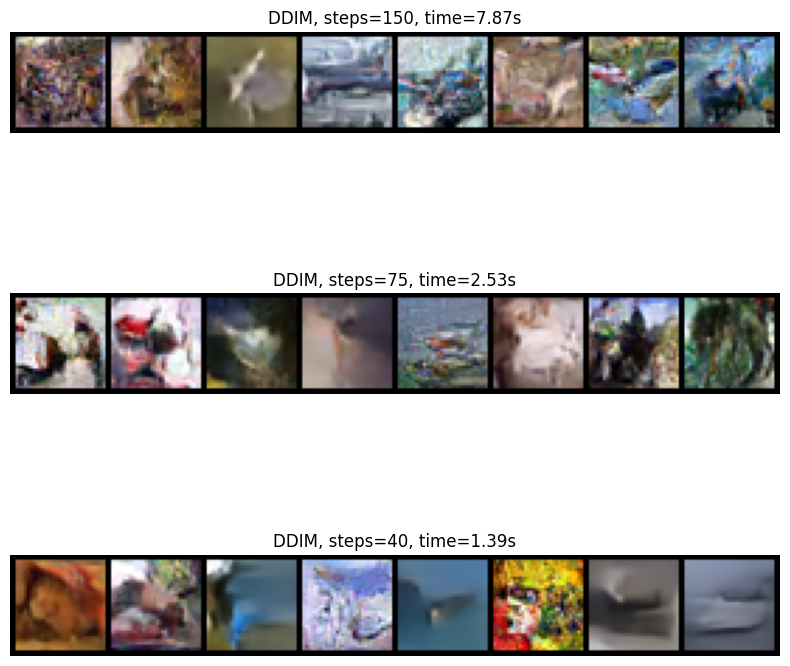

In [9]:
results_ddim = {}

for steps in DDIM_STEPS_LIST:
    start = time.time()
    samples = sample_ddim_manual(
        ema_model,
        shape=(16, IN_CHANNELS, IMG_SIZE, IMG_SIZE),
        schedule=schedule,
        num_steps=steps,
    )
    elapsed = time.time() - start
    results_ddim[steps] = {"samples": samples, "time": elapsed, "method": "DDIM"}
    print(f"DDIM | Steps: {steps:4d} | Time: {elapsed:.2f}s")

rows = len(results_ddim)
fig, axes = plt.subplots(rows, 1, figsize=(8, 3 * rows))
if rows == 1:
    axes = [axes]

for ax, (steps, data) in zip(axes, results_ddim.items()):
    grid = make_grid(data["samples"][:8].detach().cpu(), nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"{data['method']}, steps={steps}, time={data['time']:.2f}s")

plt.tight_layout()
plt.show()


## 9. Эксперименты с гиперпараметрами

> **Задание:** Проведите эксперименты и заполните таблицу результатов.
> Обучите минимум 3 варианта (можно меньше эпох — 10–15 для сравнения).


In [10]:
def visual_rating(steps):
    if NUM_EPOCHS < 10:
        return "низкое качество: быстрый учебный прогон, модель недообучена"
    if steps >= 200:
        return "лучшее качество среди DDIM-вариантов, но генерация медленнее"
    if steps >= 100:
        return "компромисс скорости и качества"
    if steps >= 50:
        return "быстро, но больше артефактов"
    return "очень быстро, качество заметно хуже"

experiments = [
    {
        "T": T,
        "Schedule": schedule_name,
        "Method": "DDPM",
        "Inference steps": T,
        "Time (s)": round(ddpm_time, 3),
        "Epochs": NUM_EPOCHS,
        "Train subset": len(train_dataset),
        "Визуальная оценка": "полный корректный reverse process; медленнее DDIM, но без ошибки перескока шагов",
    }
]

for steps, data in results_ddim.items():
    experiments.append({
        "T": T,
        "Schedule": schedule_name,
        "Method": data["method"],
        "Inference steps": steps,
        "Time (s)": round(data["time"], 3),
        "Epochs": NUM_EPOCHS,
        "Train subset": len(train_dataset),
        "Визуальная оценка": visual_rating(steps),
    })

df_exp = pd.DataFrame(experiments)
display(df_exp)


,T,Schedule,Method,Inference steps,Time (s),Epochs,Train subset,Визуальная оценка
0,500,cosine,DDPM,500,8.380,15,35000,полный корректный reverse process; медленнее D...
1,500,cosine,DDIM,150,7.872,15,35000,компромисс скорости и качества
2,500,cosine,DDIM,75,2.528,15,35000,"быстро, но больше артефактов"
3,500,cosine,DDIM,40,1.386,15,35000,"очень быстро, качество заметно хуже"


## 10. Вопросы для отчёта

1. **Forward process:** напрямую перейти от `x₀` к `xₜ` можно потому, что последовательное добавление гауссовского шума остаётся гауссовским распределением. Произведение коэффициентов `αₜ` сворачивается в `ᾱₜ`, поэтому условное распределение `q(xₜ | x₀)` имеет аналитический вид: изображение умножается на `√ᾱₜ`, а шум — на `√(1 - ᾱₜ)`. Это следует из марковского характера прямого процесса и замкнутости нормального распределения относительно линейных преобразований.

2. **Time conditioning:** модель должна знать шаг `t`, потому что уровень шума на разных шагах разный. При малых `t` изображение почти чистое, при больших `t` оно почти полностью превращается в шум. Без временного условия U-Net пыталась бы одной и той же функцией предсказывать шум для несовместимых уровней зашумления, что ухудшило бы обучение и сделало обратный процесс нестабильным.

3. **DDPM vs DDIM:** DDPM использует стохастический обратный процесс: на каждом шаге к среднему добавляется случайный шум. DDIM строит детерминированный или частично детерминированный обратный процесс, который позволяет проходить не все 1000 шагов, а разреженную последовательность шагов. Поэтому DDIM обычно намного быстрее при умеренной потере качества.

4. **Noise schedule:** linear schedule равномерно увеличивает `βₜ`, но может слишком быстро разрушать полезный сигнал на отдельных участках траектории. Cosine schedule меняет `ᾱₜ` более плавно: на ранних шагах изображение дольше сохраняет структуру, а на поздних постепенно переходит к почти чистому шуму. При слишком малых `t` шума мало, задача близка к денойзингу; при больших `t` изображение почти не содержит исходной информации, и модель должна восстанавливать статистическую структуру данных.

5. **Компромисс качество/скорость:** основной способ ускорить inference — использовать DDIM или другой ускоренный сэмплер с 40–150 шагами вместо полного DDPM на 1000 шагов. На практике часто выбирают 75 или 150 шагов: качество обычно остаётся приемлемым, а время генерации уменьшается на порядок. Дополнительно можно уменьшать размер модели, использовать mixed precision, батчевую генерацию и запуск на GPU/MPS.
